# Phase kickback

## Goal 
In this notebook, I investigate phase kickback using Qiskit.

The main question is :  
Why can the phase assoicated with an operation on the target  
appear as a relative phase on the control qubit?

In [10]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from qiskit.visualization import plot_bloch_multivector
from qiskit_aer import AerSimulator

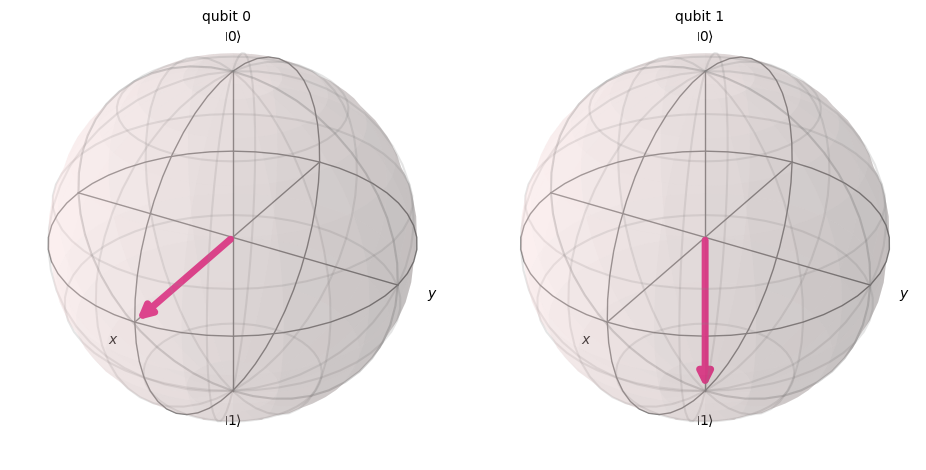

In [18]:
def init():
    qc = QuantumCircuit(2)

    qc.h(0)
    qc.x(1)
    
    return qc

qc = init()

state = Statevector.from_instruction(qc)

plot_bloch_multivector(state)


$$ |+\rangle|1\rangle = {|01\rangle + |11\rangle \over \sqrt 2} $$

### Apply CZ

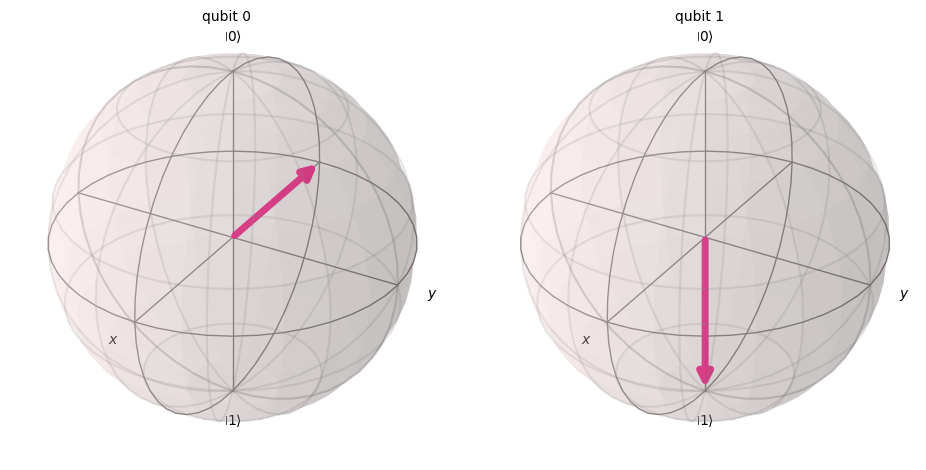

In [19]:
qc.cz(0,1)

state = Statevector.from_instruction(qc)

plot_bloch_multivector(state)


$$ |+\rangle|1\rangle={|01\rangle+ |11\rangle \over \sqrt 2 } \rightarrow  {|01\rangle - |11\rangle \over\sqrt 2} = |-\rangle|1\rangle $$


## Why does the phase kick back?

The CZ gate applies a phase of -1 only to $|11\rangle$.

The state $|1\rangle$ is an eigenstate of Z.

Therefore, $|0\rangle|1\rangle \rightarrow |0\rangle|1\rangle$

While $|1\rangle|1\rangle \rightarrow -|1\rangle|1\rangle $

Because the control qubit is in a superpostion,  
the two branches acquire different phases.

Therefore, the phase becomes a relative phase  
between the $|0\rangle $ and $|1\rangle$ components of the control qubit.


## Apply H gate to the control qubit

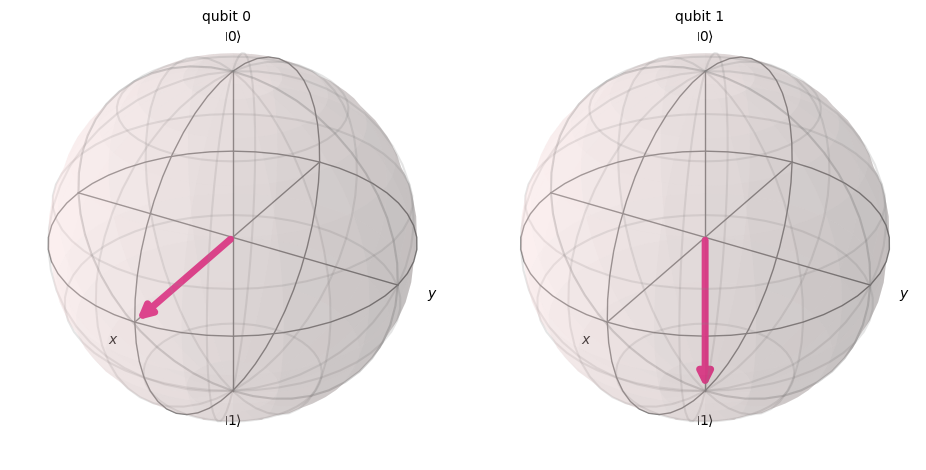

In [30]:
plus = init()

state = Statevector.from_instruction(plus)
plot_bloch_multivector(state)

In [31]:
plus.measure_all()

simulator = AerSimulator()

result = simulator.run(plus, shots=1000).result()
counts = result.get_counts()

print(counts)

{'10': 499, '11': 501}


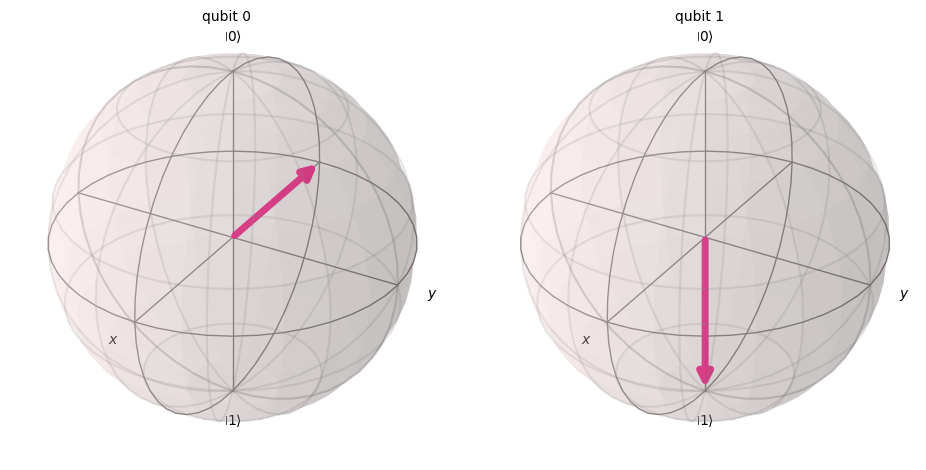

In [32]:
minus = init()

minus.cz(0, 1)

state = Statevector.from_instruction(minus)

plot_bloch_multivector(state)


In [33]:
minus.measure_all()

simulator = AerSimulator()

result = simulator.run(minus, shots=1000).result()
counts = result.get_counts()

print(counts)

{'11': 516, '10': 484}


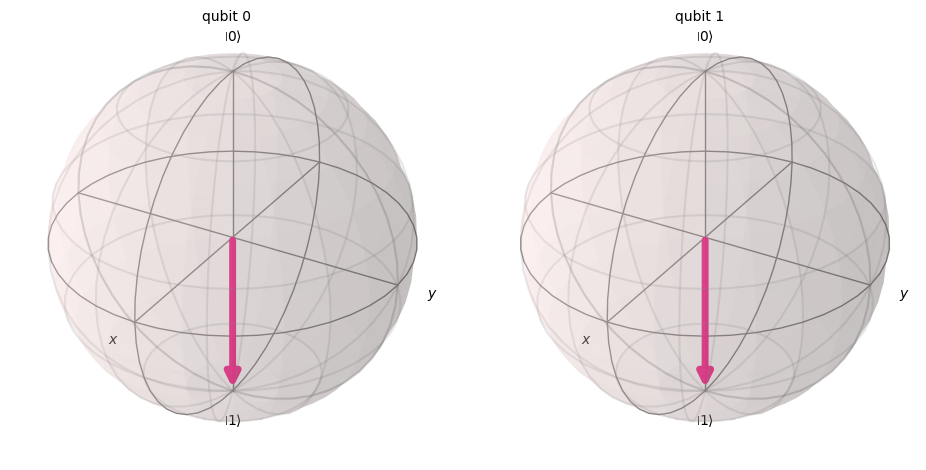

In [34]:
h = init()

h.cz(0, 1)

h.h(0)

state = Statevector.from_instruction(h)
plot_bloch_multivector(state)


In [35]:
h.measure_all()

simulator = AerSimulator()

result = simulator.run(h, shots=1000).result()
counts = result.get_counts()

print(counts)

{'11': 1000}


In [39]:
phi = sp.symbols('phi', real=True)

CP = sp.Matrix([[1, 0, 0, 0],
                 [0, 1, 0, 0],
                 [0, 0, 1, 0],
                 [0, 0, 0, sp.exp(sp.I * phi)]])


psi = sp.Matrix([0,1/ sp.sqrt(2), 0, 1/ sp.sqrt(2)]) #|+> tensor product |1>

result = CP * psi

sp.simplify(result)

Matrix([
[                   0],
[           sqrt(2)/2],
[                   0],
[sqrt(2)*exp(I*phi)/2]])

### CP($\phi$)

$ {|+\rangle|1\rangle} \rightarrow {|0\rangle + e^{i\phi}|1\rangle \over \sqrt 2}|1\rangle $  
CZ is special case of CP


### CU 

$ U|\psi\rangle = e^{i\phi}|\psi\rangle $  
$(\alpha|0\rangle + \beta|1\rangle )|\psi\rangle $  
$ CU(\alpha|0\rangle + \beta|1\rangle )|\psi\rangle = 
\alpha|0\rangle + \beta e^{i\phi}|1\rangle )|\psi\rangle $


